[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/agent/well-count-placement-workflow/notebooks/fielddevelopment/well_count_and_placement_workflow.ipynb)

# Producer and injector well-count and placement workflow

This executed engineering tutorial turns a subsurface map into an auditable decision on the
**number and placement of producers and water injectors**. It uses a robust multi-objective
optimizer to generate layouts, OPM Flow to test shortlisted layouts dynamically, and NeqSim to
carry reservoir rates into well, SURF, process-capacity, and economic screens.

The data are synthetic and public. Results are teaching and screening evidence, not a
history-matched field-development plan, reserves estimate, well proposal, or investment decision.


## Learning outcomes

After running the notebook, you should be able to:

1. translate field objectives, uncertainties, exclusions, and facility limits into layout criteria;
2. screen producer and injector counts from deliverability, injectivity, and voidage replacement;
3. use `pymoo` NSGA-II to search discrete producer/injector locations across geological realizations;
4. distinguish proxy optimization from dynamic OPM Flow verification;
5. connect selected rates to NeqSim fluid, well/SURF, separation, compression, and cooling models;
6. compare development concepts with recovery, pressure support, capacity, CAPEX, NPV, and downside; and
7. identify the evidence required before a real well-location decision.


## The work process

| Gate | Main question | Calculation or evidence | Decision output |
|---|---|---|---|
| 1. Frame | What must the development achieve? | target rate, recovery, pressure, capacity, HSE and commercial limits | objectives and hard constraints |
| 2. Characterize | Where is movable hydrocarbon and uncertainty? | structure, faults, thickness, porosity, permeability, saturation, SCAL and PVT | realizations and candidate zones |
| 3. Count | How many active producers and injectors are credible? | IPR/VLP, injectivity, fracture margin, voidage, uptime and spare philosophy | count alternatives |
| 4. Place | Which layouts balance contact, sweep, water risk and routing? | constrained multi-objective search | Pareto layouts per count |
| 5. Verify | Do dynamic conservation equations support the proxy ranking? | OPM Flow pressure, saturation, rates, breakthrough and recovery | validated shortlist |
| 6. Integrate | Can wells, SURF and facilities handle the forecast? | NeqSim fluid/process and hydraulic screens | capacities and bottlenecks |
| 7. Decide | Is incremental value robust? | CAPEX/OPEX, NPV, uncertainty and schedule | recommendation and maturation plan |

Count alternatives are separate development concepts. Geological realizations describe uncertainty
*within* each concept; they should not be mixed into one probability distribution of well count.


## Governing screening relationships

For a vertical liquid well, the radial-flow screening rate is

$$q=\frac{2\pi kh\Delta p}{\mu B\left[\ln(r_e/r_w)-0.75+s\right]}$$

where $k$ is permeability, $h$ is net thickness, $\Delta p$ is drawdown or injection
overpressure, $\mu$ is viscosity, $B$ is formation-volume factor, $r_e$ and $r_w$ are drainage
and wellbore radii, and $s$ is skin. This is a count screen, not a substitute for a calibrated
IPR/VLP or completion model.

Water injection is screened against voidage replacement:

$$\mathrm{VRR}=\frac{q_{wi}B_w}{q_oB_o+q_wB_w+q_gB_g}$$

The optimizer minimizes three competing objectives: negative robust production contact,
negative robust sweep support, and SURF routing length. Dynamic OPM Flow and economics determine
the final ranking; the proxy score does not.


## 1. Clean Colab setup

The versions are pinned to the clean runtime used for this notebook. OPM Flow is installed from
the official OPM Ubuntu PPA when it is not already available. Installation output is captured,
while version and simulation evidence remain visible.


In [1]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-well-layout-matplotlib")

from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import platform
import re
import shutil
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "opm": "2026.4",
    "pymoo": "0.6.2",
    "pyscal": "0.15.3",
}


def installed_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return None


package_specs = [
    f"{name}=={required}"
    for name, required in REQUIRED_PACKAGES.items()
    if installed_version(name) != required
]
if package_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *package_specs,
        ],
        check=True,
        timeout=900,
    )

FLOW_RUN_ENV = os.environ.copy()
if os.environ.get("OPM_FLOW_PYTHONHOME"):
    FLOW_RUN_ENV["PYTHONHOME"] = os.environ["OPM_FLOW_PYTHONHOME"]
FLOW_EXECUTABLE = os.environ.get("OPM_FLOW_EXECUTABLE") or shutil.which("flow")

if FLOW_EXECUTABLE is None:
    os_release = Path("/etc/os-release").read_text(encoding="utf-8")
    if "Ubuntu" not in os_release:
        raise RuntimeError("Automatic OPM Flow installation needs Ubuntu/Colab.")
    setup_commands = [
        ["apt-get", "update", "-qq"],
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "--no-install-recommends",
            "software-properties-common",
        ],
        ["add-apt-repository", "-y", "ppa:opm/ppa"],
        ["apt-get", "update", "-qq"],
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "--no-install-recommends",
            "libopm-simulators-bin",
        ],
    ]
    for command in setup_commands:
        completed = subprocess.run(
            command,
            capture_output=True,
            text=True,
            timeout=1200,
        )
        if completed.returncode != 0:
            raise RuntimeError(
                "OPM Flow installation failed:\n" + completed.stderr[-4000:]
            )
    FLOW_EXECUTABLE = shutil.which("flow")

if FLOW_EXECUTABLE is None:
    raise RuntimeError("OPM Flow executable was not found.")

flow_version_run = subprocess.run(
    [FLOW_EXECUTABLE, "--version"],
    capture_output=True,
    env=FLOW_RUN_ENV,
    check=True,
    text=True,
    timeout=60,
)
flow_version_text = flow_version_run.stdout + flow_version_run.stderr
flow_version_match = re.search(r"flow\s+(\d{4}\.\d{2})", flow_version_text)
if flow_version_match is None:
    raise RuntimeError("Could not identify the OPM Flow version.")

print(
    {
        "Python": platform.python_version(),
        **{name: installed_version(name) for name in REQUIRED_PACKAGES},
        "OPM Flow": flow_version_match.group(1),
    }
)


{'Python': '3.12.13', 'neqsim': '3.17.0', 'opm': '2026.4', 'pymoo': '0.6.2', 'pyscal': '0.15.3', 'OPM Flow': '2026.04'}


In [2]:
import json
import math
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist, pdist
from dateutil.parser import UnknownTimezoneWarning

from neqsim import jneqsim
from neqsim.process.processTools import (
    clearProcess,
    compressor,
    cooler,
    runProcess,
    separator3phase,
    stream,
    valve,
)
from neqsim.thermo import TPflash
from opm.io import Parser
from opm.io.ecl import ESmry
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import ElementwiseProblem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pyscal import WaterOil


warnings.filterwarnings("ignore", category=UnknownTimezoneWarning)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 125,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 8,
    }
)

RANDOM_SEED = 20260815
random_generator = np.random.default_rng(RANDOM_SEED)
SECONDS_PER_DAY = 86400.0
DAYS_PER_YEAR = 365.25
MILLI_DARCY_TO_M2 = 9.869233e-16
BAR_TO_PA = 1.0e5
GRID_NX = 24
GRID_NY = 24
GRID_NZ = 3
CELL_SIZE_M = 120.0
RESERVOIR_DEPTH_M = 2500.0
INITIAL_PRESSURE_BARA = 260.0
RESERVOIR_TEMPERATURE_C = 88.0

OUTPUT_DIRECTORY = Path("well_count_placement_outputs")
if OUTPUT_DIRECTORY.exists():
    shutil.rmtree(OUTPUT_DIRECTORY)
OUTPUT_DIRECTORY.mkdir()


## 2. Decision basis and transparent assumptions

The synthetic case represents a moderate offshore oil accumulation with heterogeneous channelized
rock. Every value below is an explicit teaching assumption. A real study would link each item to
an assumptions register, data owner, uncertainty distribution, and decision-gate maturity.


In [3]:
decision_basis = pd.DataFrame(
    [
        ("reservoir grid", "24 × 24 × 3", "cells", "synthetic model"),
        ("cell size", CELL_SIZE_M, "m", "screening assumption"),
        ("initial pressure", INITIAL_PRESSURE_BARA, "bara", "screening assumption"),
        ("temperature", RESERVOIR_TEMPERATURE_C, "°C", "screening assumption"),
        ("field oil target", 4000.0, "Sm³/d", "commercial screening target"),
        ("minimum VRR", 0.85, "fraction", "pressure-support target"),
        ("producer BHP limit", 105.0, "bara", "well/SURF screen"),
        ("injector BHP limit", 325.0, "bara", "below fracture screen"),
        ("oil facility capacity", 5600.0, "Sm³/d", "host screen"),
        ("water facility capacity", 4800.0, "Sm³/d", "host screen"),
        ("forecast", 6.0, "years", "concept comparison"),
    ],
    columns=["item", "value", "unit", "provenance"],
)
display(decision_basis)


,item,value,unit,provenance
0,reservoir grid,24 × 24 × 3,cells,synthetic model
1,cell size,120.0,m,screening assumption
2,initial pressure,260.0,bara,screening assumption
3,temperature,88.0,°C,screening assumption
4,field oil target,4000.0,Sm³/d,commercial screening target
5,minimum VRR,0.85,fraction,pressure-support target
6,producer BHP limit,105.0,bara,well/SURF screen
7,injector BHP limit,325.0,bara,below fracture screen
8,oil facility capacity,5600.0,Sm³/d,host screen
9,water facility capacity,4800.0,Sm³/d,host screen


## 3. Geological realizations and candidate zones

Five correlated permeability realizations share the same structural trend but vary the channel
continuity. Candidate locations must lie inside the reservoir, avoid the modeled fault corridor,
and exceed net-rock quality thresholds. The optimizer therefore searches only drillable screening
cells; trajectory feasibility and anti-collision remain later engineering gates.


In [4]:
x_cells, y_cells = np.meshgrid(
    np.arange(GRID_NX),
    np.arange(GRID_NY),
)
regional_trend = (
    0.9 * np.exp(-((y_cells - 0.55 * x_cells - 4.0) / 2.7) ** 2)
    + 0.7 * np.exp(-((y_cells + 0.45 * x_cells - 22.0) / 2.4) ** 2)
)

porosity = 0.17 + 0.075 * regional_trend
porosity += 0.012 * gaussian_filter(
    random_generator.normal(size=(GRID_NY, GRID_NX)),
    sigma=2.0,
)
porosity = np.clip(porosity, 0.12, 0.29)

net_thickness_m = 12.0 + 13.0 * regional_trend
net_thickness_m += 1.8 * gaussian_filter(
    random_generator.normal(size=(GRID_NY, GRID_NX)),
    sigma=2.5,
)
net_thickness_m = np.clip(net_thickness_m, 8.0, 30.0)

permeability_realizations_md = []
for realization_index in range(5):
    correlated_noise = gaussian_filter(
        random_generator.normal(size=(GRID_NY, GRID_NX)),
        sigma=1.6,
    )
    log_permeability = 5.6 + 1.25 * regional_trend + 0.75 * correlated_noise
    permeability_realizations_md.append(np.exp(log_permeability))
permeability_realizations_md = np.asarray(permeability_realizations_md)

fault_mask = (
    (x_cells >= 11)
    & (x_cells <= 12)
    & (y_cells >= 5)
    & (y_cells <= 19)
)
interior_mask = (
    (x_cells >= 2)
    & (x_cells <= GRID_NX - 3)
    & (y_cells >= 2)
    & (y_cells <= GRID_NY - 3)
)
quality_mask = (
    (porosity >= 0.17)
    & (net_thickness_m >= 13.0)
    & (np.median(permeability_realizations_md, axis=0) >= 250.0)
)
candidate_mask = interior_mask & quality_mask & ~fault_mask

candidate_locations = np.argwhere(candidate_mask)[:, [1, 0]]
candidate_table = pd.DataFrame(
    {
        "candidate": np.arange(len(candidate_locations)),
        "i": candidate_locations[:, 0] + 1,
        "j": candidate_locations[:, 1] + 1,
        "porosity": porosity[candidate_mask],
        "net thickness [m]": net_thickness_m[candidate_mask],
        "median permeability [mD]": np.median(
            permeability_realizations_md,
            axis=0,
        )[candidate_mask],
    }
)

display(candidate_table.head(10))
print(f"Candidate locations retained: {len(candidate_locations)}")


Candidate locations retained: 224


,candidate,i,j,porosity,net thickness [m],median permeability [mD]
0,0,3,3,0.189319,15.410242,329.407160
1,1,4,3,0.181632,14.065696,300.776857
2,2,5,3,0.175991,13.123236,283.588704
3,3,3,4,0.208680,18.610829,478.785877
4,4,4,4,0.196892,16.581538,412.488939
5,5,5,4,0.186789,14.890642,356.913504
6,6,6,4,0.179236,13.656204,324.429340
7,7,3,5,0.229887,22.059264,664.358977
8,8,4,5,0.218270,20.081876,549.036606
9,9,5,5,0.205452,17.954030,475.790230


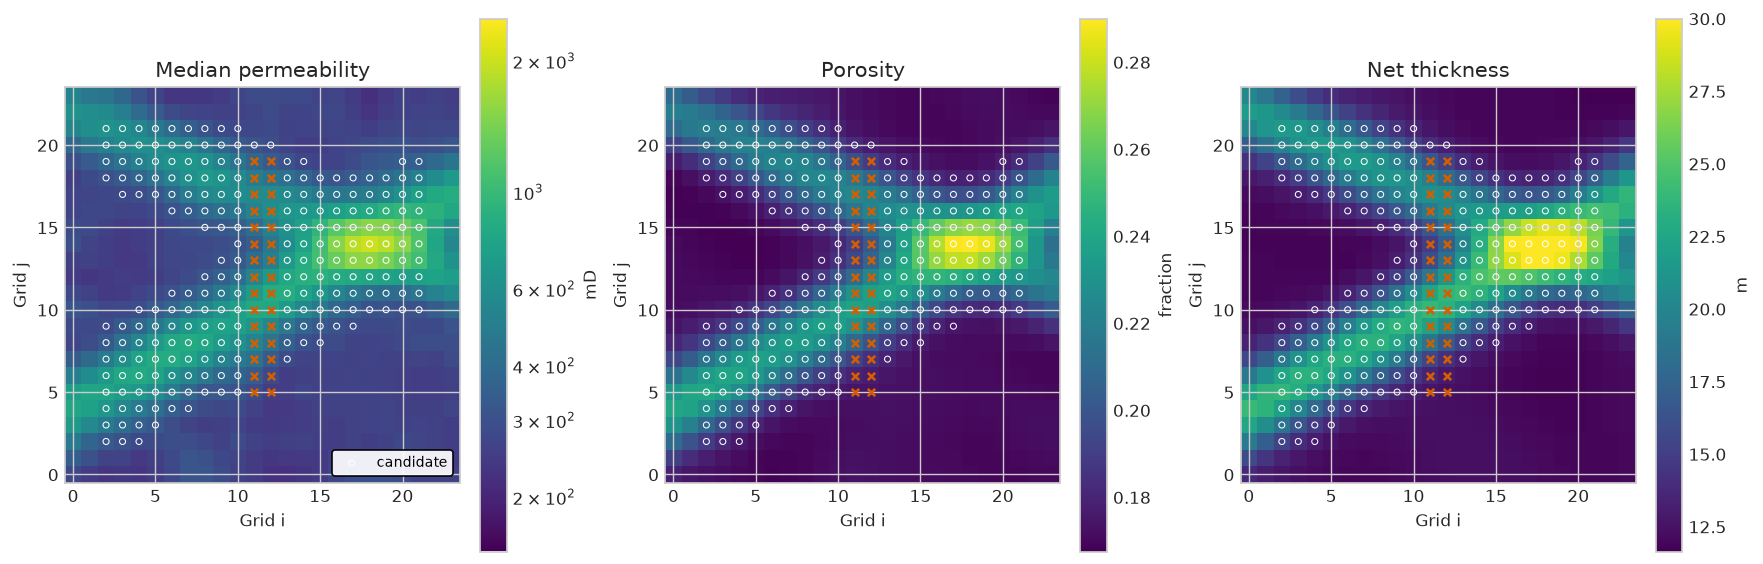

In [5]:
geology_figure, geology_axes = plt.subplots(
    1,
    3,
    figsize=(14.0, 4.4),
    constrained_layout=True,
)

map_definitions = [
    (
        np.median(permeability_realizations_md, axis=0),
        "Median permeability",
        "mD",
        LogNorm(vmin=150.0, vmax=2500.0),
    ),
    (porosity, "Porosity", "fraction", None),
    (net_thickness_m, "Net thickness", "m", None),
]
for axis, (values, title, colorbar_label, normalization) in zip(
    geology_axes,
    map_definitions,
):
    image = axis.imshow(
        values,
        origin="lower",
        cmap="viridis",
        norm=normalization,
    )
    axis.scatter(
        candidate_locations[:, 0],
        candidate_locations[:, 1],
        s=12,
        facecolors="none",
        edgecolors="white",
        linewidths=0.6,
        label="candidate",
    )
    fault_y, fault_x = np.where(fault_mask)
    axis.scatter(fault_x, fault_y, marker="x", s=18, color="#D55E00")
    axis.set(title=title, xlabel="Grid i", ylabel="Grid j")
    geology_figure.colorbar(image, ax=axis, label=colorbar_label)

geology_legend = geology_axes[0].legend(
    loc="lower right",
    facecolor="white",
    edgecolor="black",
    frameon=True,
    framealpha=0.92,
)
for legend_text in geology_legend.get_texts():
    legend_text.set_color("black")
plt.show()


## 4. SCAL and count screening

`pyscal` generates internally consistent Corey water/oil curves and an OPM `SWOF` table. The
radial screen then combines local $kh$, pressure margin, viscosity, skin, uptime, and per-well
operating caps. Injector count must also satisfy the VRR and fracture-pressure margins.


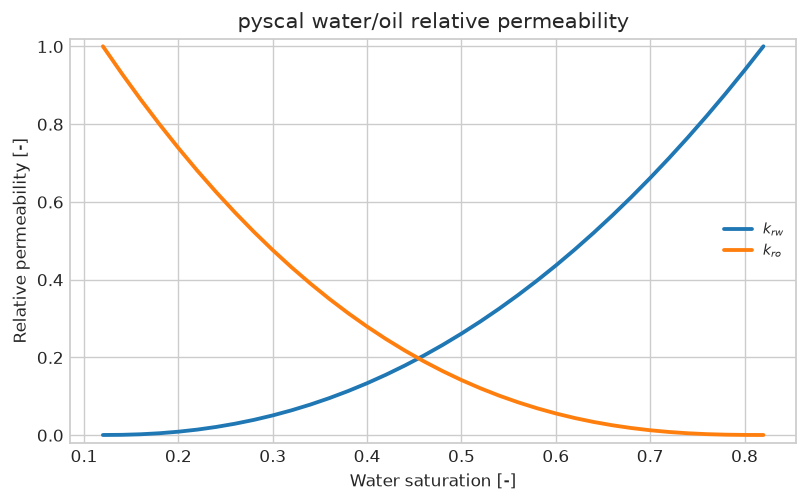

,SW,KRW,KROW
0,0.12,0.000000,1.000000
1,0.22,0.013829,0.680194
2,0.32,0.063540,0.431201
3,0.42,0.155043,0.246834
4,0.52,0.291955,0.120243
5,0.62,0.477000,0.043634
6,0.72,0.712389,0.007714
7,0.82,1.000000,0.000000


In [6]:
water_oil = WaterOil(h=0.02, sorw=0.18, swl=0.12)
water_oil.add_corey_water(nw=2.2)
water_oil.add_corey_oil(now=2.5)
swof_text = water_oil.SWOF()
scal_table = water_oil.table.loc[
    water_oil.table["SW"] <= 0.82 + 1.0e-9
].copy()

scal_figure, scal_axis = plt.subplots(figsize=(7.5, 4.2))
scal_axis.plot(
    scal_table["SW"],
    scal_table["KRW"],
    linewidth=2.2,
    label="$k_{rw}$",
)
scal_axis.plot(
    scal_table["SW"],
    scal_table["KROW"],
    linewidth=2.2,
    label="$k_{ro}$",
)
scal_axis.set(
    title="pyscal water/oil relative permeability",
    xlabel="Water saturation [-]",
    ylabel="Relative permeability [-]",
    ylim=(-0.02, 1.02),
)
scal_axis.legend()
plt.show()

display(scal_table.iloc[::5][["SW", "KRW", "KROW"]].reset_index(drop=True))


In [7]:
def radial_rate_sm3_day(
    permeability_md,
    net_thickness,
    pressure_difference_bar,
    viscosity_cp,
    formation_volume_factor,
    skin,
    drainage_radius_m=520.0,
    wellbore_radius_m=0.11,
):
    permeability_m2 = permeability_md * MILLI_DARCY_TO_M2
    pressure_difference_pa = pressure_difference_bar * BAR_TO_PA
    viscosity_pa_s = viscosity_cp * 1.0e-3
    denominator = viscosity_pa_s * formation_volume_factor
    denominator *= (
        np.log(drainage_radius_m / wellbore_radius_m) - 0.75 + skin
    )
    reservoir_rate_m3_s = (
        2.0
        * np.pi
        * permeability_m2
        * net_thickness
        * pressure_difference_pa
        / denominator
    )
    return reservoir_rate_m3_s * SECONDS_PER_DAY


median_candidate_permeability = candidate_table[
    "median permeability [mD]"
].median()
median_candidate_thickness = candidate_table["net thickness [m]"].median()

uncapped_producer_rate = radial_rate_sm3_day(
    median_candidate_permeability,
    median_candidate_thickness,
    pressure_difference_bar=95.0,
    viscosity_cp=0.85,
    formation_volume_factor=1.22,
    skin=3.0,
)
uncapped_injector_rate = radial_rate_sm3_day(
    median_candidate_permeability,
    median_candidate_thickness,
    pressure_difference_bar=65.0,
    viscosity_cp=0.48,
    formation_volume_factor=1.02,
    skin=1.0,
)

SAFE_PRODUCER_RATE_SM3_DAY = min(uncapped_producer_rate, 1850.0)
SAFE_INJECTOR_RATE_SM3_DAY = min(uncapped_injector_rate, 3300.0)
FIELD_OIL_TARGET_SM3_DAY = 4000.0
REQUIRED_WATER_INJECTION_SM3_DAY = (
    FIELD_OIL_TARGET_SM3_DAY * 1.22 * 0.90 / 1.02
)

COUNT_CONCEPTS = {
    "3P1I": (3, 1),
    "4P2I": (4, 2),
    "5P2I": (5, 2),
    "6P3I": (6, 3),
}

count_rows = []
for concept_name, (producer_count, injector_count) in COUNT_CONCEPTS.items():
    production_capacity = producer_count * SAFE_PRODUCER_RATE_SM3_DAY
    injection_capacity = injector_count * SAFE_INJECTOR_RATE_SM3_DAY
    count_rows.append(
        {
            "concept": concept_name,
            "producers": producer_count,
            "injectors": injector_count,
            "oil capacity [Sm3/d]": production_capacity,
            "injection capacity [Sm3/d]": injection_capacity,
            "oil target met": production_capacity >= FIELD_OIL_TARGET_SM3_DAY,
            "VRR target met": injection_capacity >= REQUIRED_WATER_INJECTION_SM3_DAY,
        }
    )

count_screen = pd.DataFrame(count_rows)
display(count_screen)
print(
    "Representative safe rates: "
    f"producer {SAFE_PRODUCER_RATE_SM3_DAY:.0f} Sm³/d, "
    f"injector {SAFE_INJECTOR_RATE_SM3_DAY:.0f} Sm³/d"
)


Representative safe rates: producer 1850 Sm³/d, injector 3300 Sm³/d


,concept,producers,injectors,oil capacity [Sm3/d],injection capacity [Sm3/d],oil target met,VRR target met
0,3P1I,3,1,5550.0,3300.0,True,False
1,4P2I,4,2,7400.0,6600.0,True,True
2,5P2I,5,2,9250.0,6600.0,True,True
3,6P3I,6,3,11100.0,9900.0,True,True


## 5. Robust multi-objective placement with `pymoo`

Each integer decision variable points to one candidate cell. The first variables are producers and
the remaining variables are injectors. Hard constraints reject duplicates, short producer spacing,
short injector spacing, producer–injector short circuits, and producers without nearby pressure
support.

The proxy is evaluated across all five geology realizations. It rewards conservative production
contact and reservoir coverage while penalizing long routes to a central host. It deliberately
does not claim to solve the reservoir equations; OPM Flow verifies the selected Pareto layouts.


In [8]:
HOST_LOCATION = np.array([GRID_NX / 2.0, -3.0])
MIN_PRODUCER_SPACING_CELLS = 3.5
MIN_INJECTOR_SPACING_CELLS = 4.0
MIN_PRODUCER_INJECTOR_SPACING_CELLS = 3.0
MAX_SUPPORT_DISTANCE_CELLS = 12.0

grid_locations = np.column_stack((x_cells.ravel(), y_cells.ravel()))
grid_hcpv_weights = (
    porosity * net_thickness_m * (1.0 - 0.12)
).ravel()
grid_hcpv_weights /= grid_hcpv_weights.sum()


def layout_metrics(decision, producer_count, injector_count):
    candidate_indices = np.rint(decision).astype(int)
    candidate_indices = np.clip(
        candidate_indices,
        0,
        len(candidate_locations) - 1,
    )
    producer_locations = candidate_locations[
        candidate_indices[:producer_count]
    ]
    injector_locations = candidate_locations[
        candidate_indices[producer_count:]
    ]

    producer_grid_indices = (
        producer_locations[:, 1],
        producer_locations[:, 0],
    )
    production_realizations = []
    sweep_realizations = []

    producer_distances = cdist(grid_locations, producer_locations)
    injector_distances = cdist(grid_locations, injector_locations)
    nearest_producer_distance = producer_distances.min(axis=1)
    nearest_injector_distance = injector_distances.min(axis=1)
    coverage_shape = np.exp(-nearest_producer_distance / 5.5)
    coverage_shape *= np.exp(-nearest_injector_distance / 6.5)

    for permeability_map in permeability_realizations_md:
        producer_kh = (
            permeability_map[producer_grid_indices]
            * net_thickness_m[producer_grid_indices]
        )
        overlap_factor = 1.0
        if producer_count > 1:
            pair_distances = pdist(producer_locations)
            overlap_factor -= 0.18 * np.mean(np.exp(-pair_distances / 3.0))
        support_distances = cdist(
            producer_locations,
            injector_locations,
        ).min(axis=1)
        support_factor = np.mean(np.exp(-support_distances / 10.0))
        production_score = np.sum(np.sqrt(producer_kh))
        production_score *= overlap_factor * (0.82 + 0.32 * support_factor)
        production_realizations.append(production_score)

        permeability_weight = permeability_map.ravel()
        permeability_weight /= permeability_weight.mean()
        sweep_score = np.sum(
            grid_hcpv_weights * permeability_weight * coverage_shape
        )
        sweep_realizations.append(sweep_score)

    route_length_km = np.sum(
        np.linalg.norm(producer_locations - HOST_LOCATION, axis=1)
    )
    route_length_km += 0.8 * np.sum(
        np.linalg.norm(injector_locations - HOST_LOCATION, axis=1)
    )
    route_length_km *= CELL_SIZE_M / 1000.0

    all_locations = np.vstack((producer_locations, injector_locations))
    duplicate_violation = len(all_locations) - len(np.unique(all_locations, axis=0))
    producer_spacing = (
        pdist(producer_locations).min() if producer_count > 1 else 99.0
    )
    injector_spacing = (
        pdist(injector_locations).min() if injector_count > 1 else 99.0
    )
    producer_injector_distances = cdist(
        producer_locations,
        injector_locations,
    )
    short_circuit_distance = producer_injector_distances.min()
    worst_support_distance = producer_injector_distances.min(axis=1).max()

    objectives = np.array(
        [
            -np.quantile(production_realizations, 0.10),
            -np.quantile(sweep_realizations, 0.10),
            route_length_km,
        ]
    )
    constraints = np.array(
        [
            duplicate_violation,
            MIN_PRODUCER_SPACING_CELLS - producer_spacing,
            MIN_INJECTOR_SPACING_CELLS - injector_spacing,
            MIN_PRODUCER_INJECTOR_SPACING_CELLS - short_circuit_distance,
            worst_support_distance - MAX_SUPPORT_DISTANCE_CELLS,
        ]
    )
    return objectives, constraints, producer_locations, injector_locations


class WellLayoutProblem(ElementwiseProblem):
    def __init__(self, producer_count, injector_count):
        self.producer_count = producer_count
        self.injector_count = injector_count
        super().__init__(
            n_var=producer_count + injector_count,
            n_obj=3,
            n_ieq_constr=5,
            xl=0,
            xu=len(candidate_locations) - 1,
            vtype=int,
        )

    def _evaluate(self, decision, out, *args, **kwargs):
        objectives, constraints, _, _ = layout_metrics(
            decision,
            self.producer_count,
            self.injector_count,
        )
        out["F"] = objectives
        out["G"] = constraints


In [9]:
optimization_results = {}
selected_layouts = {}
pareto_rows = []

for concept_index, (
    concept_name,
    (producer_count, injector_count),
) in enumerate(COUNT_CONCEPTS.items()):
    problem = WellLayoutProblem(producer_count, injector_count)
    algorithm = NSGA2(
        pop_size=70,
        sampling=IntegerRandomSampling(),
        crossover=SBX(
            prob=0.90,
            eta=15,
            vtype=float,
            repair=RoundingRepair(),
        ),
        mutation=PM(
            eta=20,
            vtype=float,
            repair=RoundingRepair(),
        ),
        eliminate_duplicates=True,
    )
    result = minimize(
        problem,
        algorithm,
        termination=("n_gen", 55),
        seed=RANDOM_SEED + concept_index,
        verbose=False,
    )
    if result.X is None or result.F is None:
        raise RuntimeError(f"No feasible Pareto layouts found for {concept_name}.")

    decisions = np.atleast_2d(result.X)
    objectives = np.atleast_2d(result.F)
    normalized_objectives = (
        objectives - objectives.min(axis=0)
    ) / np.maximum(np.ptp(objectives, axis=0), 1.0e-12)
    compromise_score = (
        0.45 * normalized_objectives[:, 0]
        + 0.35 * normalized_objectives[:, 1]
        + 0.20 * normalized_objectives[:, 2]
    )
    selected_index = int(np.argmin(compromise_score))
    selected_decision = decisions[selected_index]
    selected_objectives = objectives[selected_index]
    _, selected_constraints, producers, injectors = layout_metrics(
        selected_decision,
        producer_count,
        injector_count,
    )

    optimization_results[concept_name] = result
    selected_layouts[concept_name] = {
        "decision": np.rint(selected_decision).astype(int),
        "producers": producers,
        "injectors": injectors,
        "objectives": selected_objectives,
        "constraints": selected_constraints,
    }

    for row in objectives:
        pareto_rows.append(
            {
                "concept": concept_name,
                "robust production contact": -row[0],
                "robust sweep support": -row[1],
                "route length [km]": row[2],
            }
        )

selected_layout_table = pd.DataFrame(
    [
        {
            "concept": concept_name,
            "producers": len(layout["producers"]),
            "injectors": len(layout["injectors"]),
            "robust production contact": -layout["objectives"][0],
            "robust sweep support": -layout["objectives"][1],
            "route length [km]": layout["objectives"][2],
            "maximum constraint": layout["constraints"].max(),
        }
        for concept_name, layout in selected_layouts.items()
    ]
)
display(selected_layout_table)


,concept,producers,injectors,robust production contact,robust sweep support,route length [km],maximum constraint
0,3P1I,3,1,22.136412,0.263365,6.583146,0.0
1,4P2I,4,2,31.245318,0.328719,9.384570,0.0
2,5P2I,5,2,34.229239,0.349466,13.474884,0.0
3,6P3I,6,3,39.360699,0.403288,15.320253,0.0


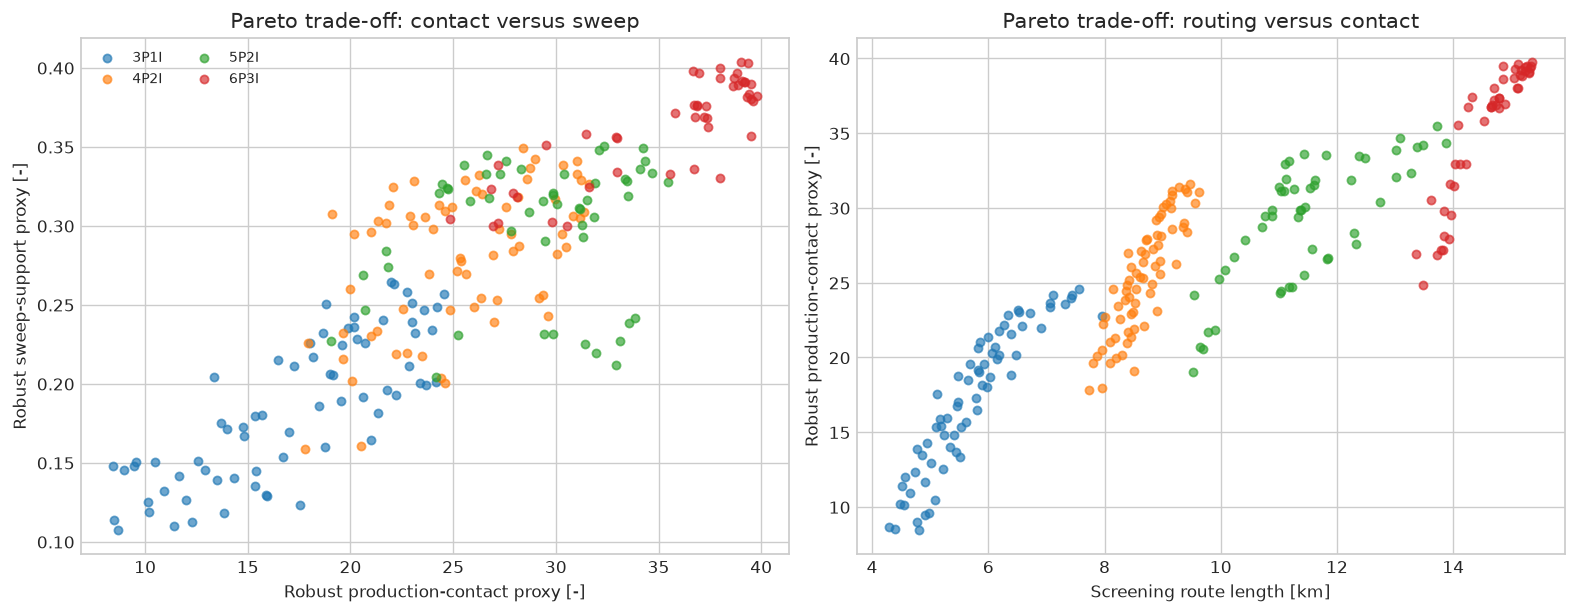

In [10]:
pareto_table = pd.DataFrame(pareto_rows)
pareto_figure, pareto_axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.8),
    constrained_layout=True,
)

for concept_name, concept_points in pareto_table.groupby("concept"):
    pareto_axes[0].scatter(
        concept_points["robust production contact"],
        concept_points["robust sweep support"],
        s=22,
        alpha=0.65,
        label=concept_name,
    )
    pareto_axes[1].scatter(
        concept_points["route length [km]"],
        concept_points["robust production contact"],
        s=22,
        alpha=0.65,
        label=concept_name,
    )

pareto_axes[0].set(
    title="Pareto trade-off: contact versus sweep",
    xlabel="Robust production-contact proxy [-]",
    ylabel="Robust sweep-support proxy [-]",
)
pareto_axes[1].set(
    title="Pareto trade-off: routing versus contact",
    xlabel="Screening route length [km]",
    ylabel="Robust production-contact proxy [-]",
)
pareto_axes[0].legend(ncol=2)
plt.show()


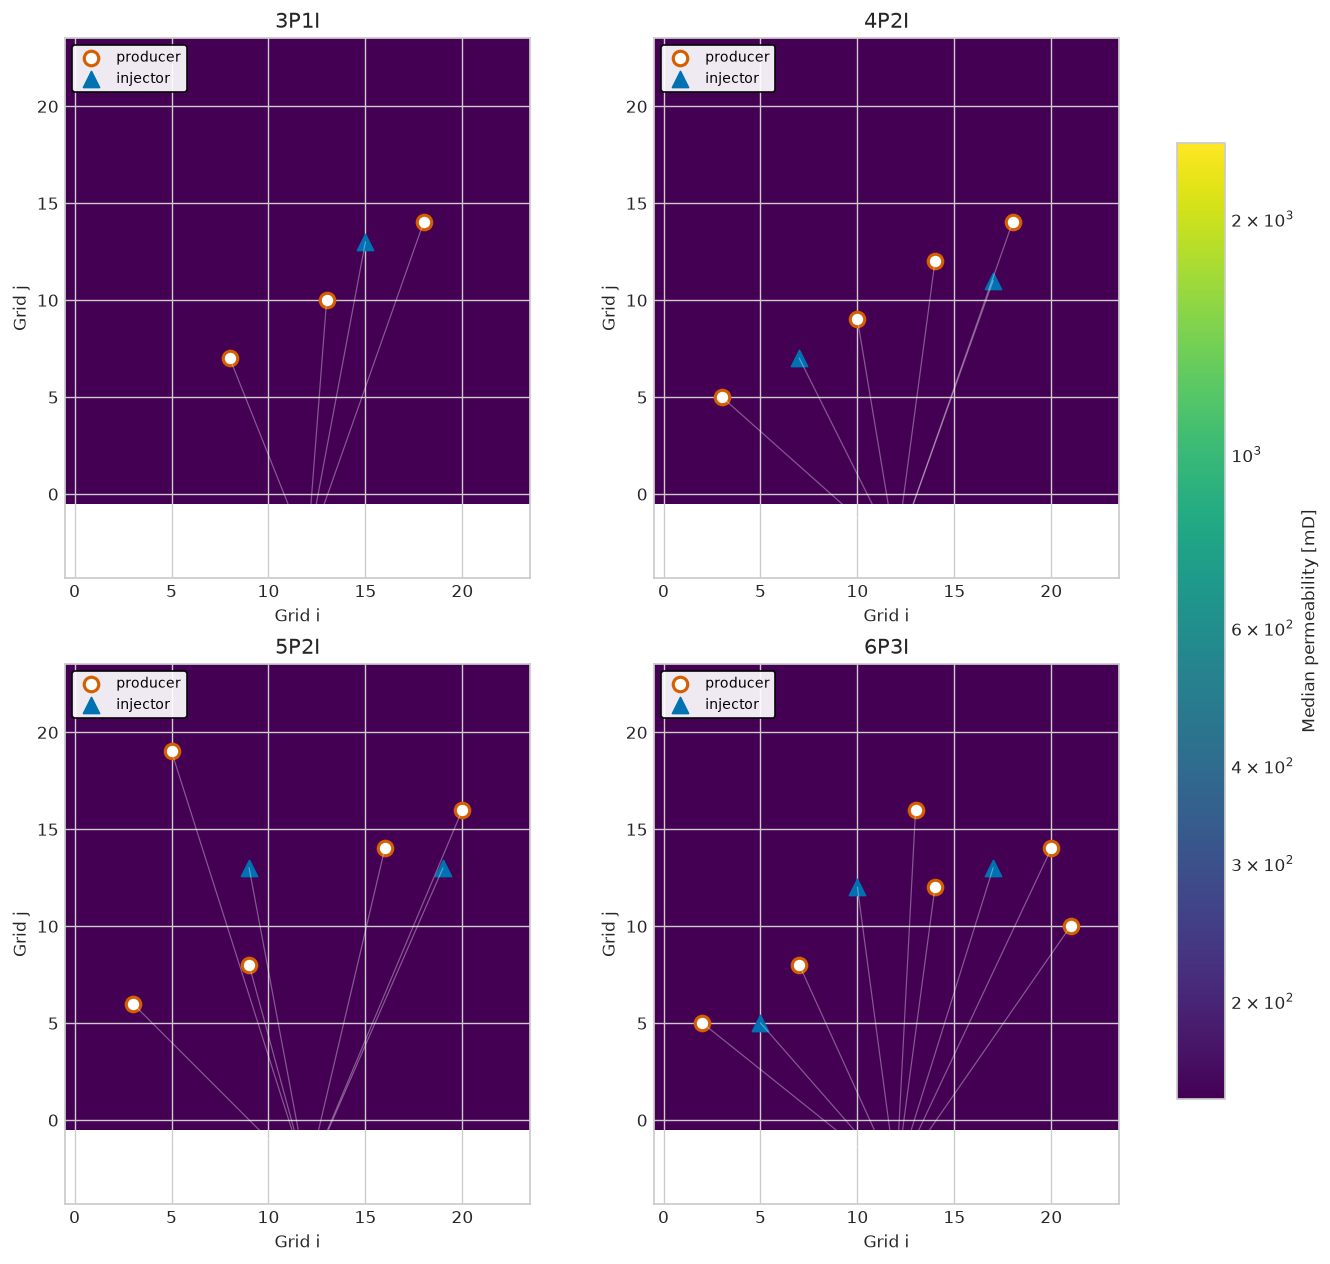

In [11]:
layout_figure, layout_axes = plt.subplots(
    2,
    2,
    figsize=(11.0, 10.0),
    constrained_layout=True,
)
median_permeability = np.median(permeability_realizations_md, axis=0)

for axis, (concept_name, layout) in zip(
    layout_axes.ravel(),
    selected_layouts.items(),
):
    image = axis.imshow(
        median_permeability,
        origin="lower",
        cmap="viridis",
        norm=LogNorm(vmin=150.0, vmax=2500.0),
    )
    axis.scatter(
        layout["producers"][:, 0],
        layout["producers"][:, 1],
        marker="o",
        s=70,
        facecolors="white",
        edgecolors="#D55E00",
        linewidths=1.8,
        label="producer",
    )
    axis.scatter(
        layout["injectors"][:, 0],
        layout["injectors"][:, 1],
        marker="^",
        s=85,
        color="#0072B2",
        label="injector",
    )
    for location in np.vstack((layout["producers"], layout["injectors"])):
        axis.plot(
            [location[0], HOST_LOCATION[0]],
            [location[1], HOST_LOCATION[1]],
            color="white",
            alpha=0.35,
            linewidth=0.7,
        )
    axis.set(title=concept_name, xlabel="Grid i", ylabel="Grid j")
    layout_legend = axis.legend(
        loc="upper left",
        facecolor="white",
        edgecolor="black",
        frameon=True,
        framealpha=0.92,
    )
    for legend_text in layout_legend.get_texts():
        legend_text.set_color("black")

layout_figure.colorbar(
    image,
    ax=layout_axes.ravel().tolist(),
    label="Median permeability [mD]",
    shrink=0.82,
)
plt.show()


## 6. NeqSim PVT contract for OPM Flow

NeqSim characterizes a synthetic dead-oil proxy with PR EOS and classic mixing. Density and
viscosity are evaluated over the simulator pressure range to build `PVDO`. NeqSim SRK-CPA supplies
water density, viscosity, formation-volume factor, and compressibility for `PVTW`.

This two-phase oil/water model isolates the well-count and waterflood decision. It does not model
solution-gas evolution; a compositional or live-oil model is required when GOR behavior materially
changes well or facility decisions.


In [12]:
OIL_COMPONENTS = [
    ("n-hexane", 0.05),
    ("n-heptane", 0.10),
    ("n-octane", 0.18),
    ("n-nonane", 0.20),
    ("nC10", 0.20),
    ("nC12", 0.17),
    ("nC16", 0.10),
]


def build_dead_oil(temperature_c, pressure_bara):
    oil = jneqsim.thermo.system.SystemPrEos(
        temperature_c + 273.15,
        pressure_bara,
    )
    for component_name, amount in OIL_COMPONENTS:
        oil.addComponent(component_name, amount)
    oil.setMixingRule("classic")
    oil.useVolumeCorrection(True)
    TPflash(oil)
    oil.initPhysicalProperties()
    return oil


def build_water(temperature_c, pressure_bara):
    water = jneqsim.thermo.system.SystemSrkCPAstatoil(
        temperature_c + 273.15,
        pressure_bara,
    )
    water.addComponent("water", 1.0)
    water.setMixingRule(10)
    TPflash(water)
    water.initPhysicalProperties()
    return water


standard_oil = build_dead_oil(15.0, 1.01325)
standard_oil_density = standard_oil.getPhase("oil").getDensity("kg/m3")

pvdo_rows = []
for pressure_bara in [80.0, 120.0, 180.0, 240.0, 300.0, 340.0]:
    oil_state = build_dead_oil(RESERVOIR_TEMPERATURE_C, pressure_bara)
    oil_density = oil_state.getPhase("oil").getDensity("kg/m3")
    pvdo_rows.append(
        {
            "pressure [bara]": pressure_bara,
            "Bo [rm3/Sm3]": standard_oil_density / oil_density,
            "viscosity [cP]": oil_state.getPhase("oil").getViscosity("cP"),
        }
    )
pvdo_table = pd.DataFrame(pvdo_rows)

standard_water = build_water(15.0, 1.01325)
reference_water = build_water(
    RESERVOIR_TEMPERATURE_C,
    INITIAL_PRESSURE_BARA,
)
low_pressure_water = build_water(
    RESERVOIR_TEMPERATURE_C,
    INITIAL_PRESSURE_BARA - 1.0,
)
high_pressure_water = build_water(
    RESERVOIR_TEMPERATURE_C,
    INITIAL_PRESSURE_BARA + 1.0,
)

standard_water_density = standard_water.getPhase("aqueous").getDensity("kg/m3")
reference_water_density = reference_water.getPhase("aqueous").getDensity("kg/m3")
water_fvf = standard_water_density / reference_water_density
water_compressibility_per_bar = (
    high_pressure_water.getPhase("aqueous").getDensity("kg/m3")
    - low_pressure_water.getPhase("aqueous").getDensity("kg/m3")
) / (2.0 * reference_water_density)
water_viscosity_cp = reference_water.getPhase("aqueous").getViscosity("cP")

display(pvdo_table)


,pressure [bara],Bo [rm3/Sm3],viscosity [cP]
0,80.0,1.046804,0.545990
1,120.0,1.039199,0.597825
2,180.0,1.029335,0.672680
3,240.0,1.020911,0.744548
4,300.0,1.013604,0.813776
5,340.0,1.009238,0.858579


In [13]:
pvdo_lines = ["PVDO"]
for _, row in pvdo_table.iterrows():
    pvdo_lines.append(
        "  "
        f"{row['pressure [bara]']:.8f} "
        f"{row['Bo [rm3/Sm3]']:.8f} "
        f"{row['viscosity [cP]']:.8f}"
    )
pvdo_lines.append("/")

black_oil_include = "\n".join(
    [
        "-- NeqSim PR dead-oil and SRK-CPA water properties",
        "DENSITY",
        f"  {standard_oil_density:.8f} {standard_water_density:.8f} 1.2 /",
        "",
        *pvdo_lines,
        "",
        "PVTW",
        (
            f"  {INITIAL_PRESSURE_BARA:.8f} "
            f"{water_fvf:.8f} "
            f"{water_compressibility_per_bar:.10e} "
            f"{water_viscosity_cp:.8f} 0.0 /"
        ),
        "",
    ]
)

pvt_checks = pd.DataFrame(
    {
        "contract": [
            "PVDO pressure increases",
            "PVDO Bo decreases under compression",
            "positive oil viscosity",
            "positive water compressibility",
        ],
        "passed": [
            np.all(np.diff(pvdo_table["pressure [bara]"]) > 0.0),
            np.all(np.diff(pvdo_table["Bo [rm3/Sm3]"]) < 0.0),
            np.all(pvdo_table["viscosity [cP]"] > 0.0),
            water_compressibility_per_bar > 0.0,
        ],
    }
)
display(pvt_checks)


,contract,passed
0,PVDO pressure increases,True
1,PVDO Bo decreases under compression,True
2,positive oil viscosity,True
3,positive water compressibility,True


## 7. Dynamic verification with OPM Flow

The same grid, rock, PVT, SCAL, dates, well controls, and facility-independent limits are used for
every concept. Only the optimized producer and injector count/locations change. Each producer has
an oil-rate target and BHP floor; total injection aims at 90% voidage but each injector has a safe
rate cap and BHP ceiling. Connection factors are derived from the radial safe-rate screen and
distributed over the modeled completion cells, keeping the count and dynamic models consistent.


In [14]:
def format_grid_values(values, values_per_line=8):
    flat_values = np.asarray(values).ravel(order="C")
    lines = []
    for start_index in range(0, len(flat_values), values_per_line):
        chunk = flat_values[start_index : start_index + values_per_line]
        lines.append("  " + " ".join(f"{value:.8g}" for value in chunk))
    return "\n".join(lines)


def build_flow_deck(concept_name, layout):
    producers = layout["producers"]
    injectors = layout["injectors"]
    total_wells = len(producers) + len(injectors)
    producer_names = [f"P{index + 1}" for index in range(len(producers))]
    injector_names = [f"I{index + 1}" for index in range(len(injectors))]
    producer_connection_factor = SAFE_PRODUCER_RATE_SM3_DAY / (
        (INITIAL_PRESSURE_BARA - 105.0) * 15.0
    )
    injector_connection_factor = SAFE_INJECTOR_RATE_SM3_DAY / (
        (325.0 - INITIAL_PRESSURE_BARA) * 3.0
    )

    wellspec_lines = ["WELSPECS"]
    completion_lines = ["COMPDAT"]
    for well_name, location in zip(producer_names, producers):
        i_index = int(location[0]) + 1
        j_index = int(location[1]) + 1
        wellspec_lines.append(
            f"  '{well_name}' 'WELLS' {i_index} {j_index} "
            f"{RESERVOIR_DEPTH_M:.1f} 'OIL' /"
        )
        for i_offset in range(-2, 3):
            completion_lines.append(
                f"  '{well_name}' {i_index + i_offset} {j_index} "
                f"1 3 'OPEN' 1* {producer_connection_factor:.8f} 0.15 /"
            )
    for well_name, location in zip(injector_names, injectors):
        i_index = int(location[0]) + 1
        j_index = int(location[1]) + 1
        wellspec_lines.append(
            f"  '{well_name}' 'WELLS' {i_index} {j_index} "
            f"{RESERVOIR_DEPTH_M:.1f} 'WATER' /"
        )
        completion_lines.append(
            f"  '{well_name}' {i_index} {j_index} 1 3 'OPEN' 1* "
            f"{injector_connection_factor:.8f} 0.15 /"
        )
    wellspec_lines.append("/")
    completion_lines.append("/")

    production_control_lines = ["WCONPROD"]
    for well_name in producer_names:
        production_control_lines.append(
            f"  '{well_name}' 'OPEN' 'ORAT' 1050.0 4* 105.0 /"
        )
    production_control_lines.append("/")

    total_target_injection = 1050.0 * len(producers) * 1.22 * 0.90 / 1.02
    injection_rate_per_well = min(
        total_target_injection / len(injectors),
        SAFE_INJECTOR_RATE_SM3_DAY,
    )
    injection_control_lines = ["WCONINJE"]
    for well_name in injector_names:
        injection_control_lines.append(
            f"  '{well_name}' 'WATER' 'OPEN' 'RATE' "
            f"{injection_rate_per_well:.6f} 1* 325.0 /"
        )
    injection_control_lines.append("/")

    layer_multipliers = np.array([1.0, 0.65, 0.35])[:, None, None]
    thickness_cube = np.broadcast_to(
        net_thickness_m[None, :, :] / GRID_NZ,
        (GRID_NZ, GRID_NY, GRID_NX),
    )
    porosity_cube = np.broadcast_to(
        porosity[None, :, :],
        (GRID_NZ, GRID_NY, GRID_NX),
    )
    permeability_x_cube = median_permeability[None, :, :] * layer_multipliers

    deck_sections = [
        "RUNSPEC",
        f"TITLE\n  {concept_name} optimized well layout /",
        "DIMENS",
        f"  {GRID_NX} {GRID_NY} {GRID_NZ} /",
        "OIL",
        "WATER",
        "METRIC",
        "TABDIMS\n  1 1 20 20 1 20 /",
        "EQLDIMS\n/",
        "START\n  1 'JAN' 2027 /",
        f"WELLDIMS\n  {total_wells} 15 1 {total_wells} /",
        "UNIFOUT",
        "GRID",
        "INIT",
        "DX\n" + f"  {GRID_NX * GRID_NY * GRID_NZ}*{CELL_SIZE_M} /",
        "DY\n" + f"  {GRID_NX * GRID_NY * GRID_NZ}*{CELL_SIZE_M} /",
        "DZ\n" + format_grid_values(thickness_cube) + "\n/",
        "TOPS\n" + f"  {GRID_NX * GRID_NY}*{RESERVOIR_DEPTH_M} /",
        "PORO\n" + format_grid_values(porosity_cube) + "\n/",
        "PERMX\n" + format_grid_values(permeability_x_cube) + "\n/",
        "PERMY\n" + format_grid_values(permeability_x_cube * 0.75) + "\n/",
        "PERMZ\n" + format_grid_values(permeability_x_cube * 0.08) + "\n/",
        "PROPS",
        black_oil_include,
        swof_text,
        "SOLUTION",
        f"EQUIL\n  {RESERVOIR_DEPTH_M:.1f} {INITIAL_PRESSURE_BARA:.8f} "
        "2600.0 0.0 2400.0 0.0 1 0 0 /",
        "SUMMARY",
        "FPR",
        "FOPR",
        "FWPR",
        "FWIR",
        "FOPT",
        "FWPT",
        "FWIT",
        "SCHEDULE",
        "RPTRST\n  'BASIC=1' /",
        "GRUPTREE\n  'WELLS' 'FIELD' /\n/",
        "\n".join(wellspec_lines),
        "\n".join(completion_lines),
        "\n".join(production_control_lines),
        "\n".join(injection_control_lines),
        "TSTEP\n  24*91.3125 /",
        "END",
    ]
    return "\n\n".join(deck_sections) + "\n"


flow_decks = {}
for concept_name, layout in selected_layouts.items():
    flow_decks[concept_name] = build_flow_deck(concept_name, layout)

example_deck_path = OUTPUT_DIRECTORY / "5P2I.DATA"
example_deck_path.write_text(flow_decks["5P2I"], encoding="utf-8")
parsed_example = Parser().parse(str(example_deck_path))
print(
    "Deck contract:",
    {
        keyword: keyword in parsed_example
        for keyword in ["DIMENS", "PVDO", "PVTW", "SWOF", "WELSPECS"]
    },
)


Deck contract: {'DIMENS': True, 'PVDO': True, 'PVTW': True, 'SWOF': True, 'WELSPECS': True}


In [15]:
reservoir_histories = {}
flow_run_rows = []

for concept_name, deck_text in flow_decks.items():
    case_directory = OUTPUT_DIRECTORY / concept_name
    case_directory.mkdir(exist_ok=True)
    deck_stem = concept_name.upper()
    deck_path = case_directory / f"{deck_stem}.DATA"
    deck_path.write_text(deck_text, encoding="utf-8")

    flow_run = subprocess.run(
        [FLOW_EXECUTABLE, deck_path.name],
        cwd=case_directory,
        env=FLOW_RUN_ENV,
        capture_output=True,
        text=True,
        timeout=600,
    )
    console_log = flow_run.stdout + "\n" + flow_run.stderr
    (case_directory / "flow-console.log").write_text(
        console_log,
        encoding="utf-8",
    )
    if flow_run.returncode != 0:
        raise RuntimeError(
            f"OPM Flow failed for {concept_name}:\n" + console_log[-5000:]
        )

    summary_path = case_directory / f"{deck_stem}.SMSPEC"
    summary = ESmry(str(summary_path))

    def summary_values(keyword):
        return np.asarray(summary[keyword], dtype=float)

    history = pd.DataFrame(
        {
            "date": pd.to_datetime(summary.dates()),
            "time [day]": summary_values("TIME"),
            "pressure [bara]": summary_values("FPR"),
            "oil rate [Sm3/d]": summary_values("FOPR"),
            "water rate [Sm3/d]": summary_values("FWPR"),
            "water injection [Sm3/d]": summary_values("FWIR"),
            "cumulative oil [MSm3]": summary_values("FOPT") / 1.0e6,
            "cumulative water [MSm3]": summary_values("FWPT") / 1.0e6,
            "cumulative injection [MSm3]": summary_values("FWIT") / 1.0e6,
        }
    )
    history["concept"] = concept_name
    reservoir_histories[concept_name] = history
    flow_run_rows.append(
        {
            "concept": concept_name,
            "return code": flow_run.returncode,
            "report points": len(history),
            "completion marker": "End of simulation" in console_log,
            "summary exists": summary_path.exists(),
        }
    )

flow_run_table = pd.DataFrame(flow_run_rows)
display(flow_run_table)


,concept,return code,report points,completion marker,summary exists
0,3P1I,0,29,True,True
1,4P2I,0,29,True,True
2,5P2I,0,31,True,True
3,6P3I,0,31,True,True


,concept,peak oil [Sm3/d],oil at 6 y [MSm3],final pressure [bara],peak water [Sm3/d],water breakthrough [year],injected water [MSm3]
3,6P3I,6300.0,1.042265,155.349152,164.240845,1.50,0.832484
2,5P2I,5250.0,0.828107,142.972214,74.029068,2.00,0.491670
1,4P2I,4200.0,0.624715,158.805664,3.846267,4.75,0.291583
0,3P1I,3150.0,0.623037,165.455978,38.005093,2.75,0.336039


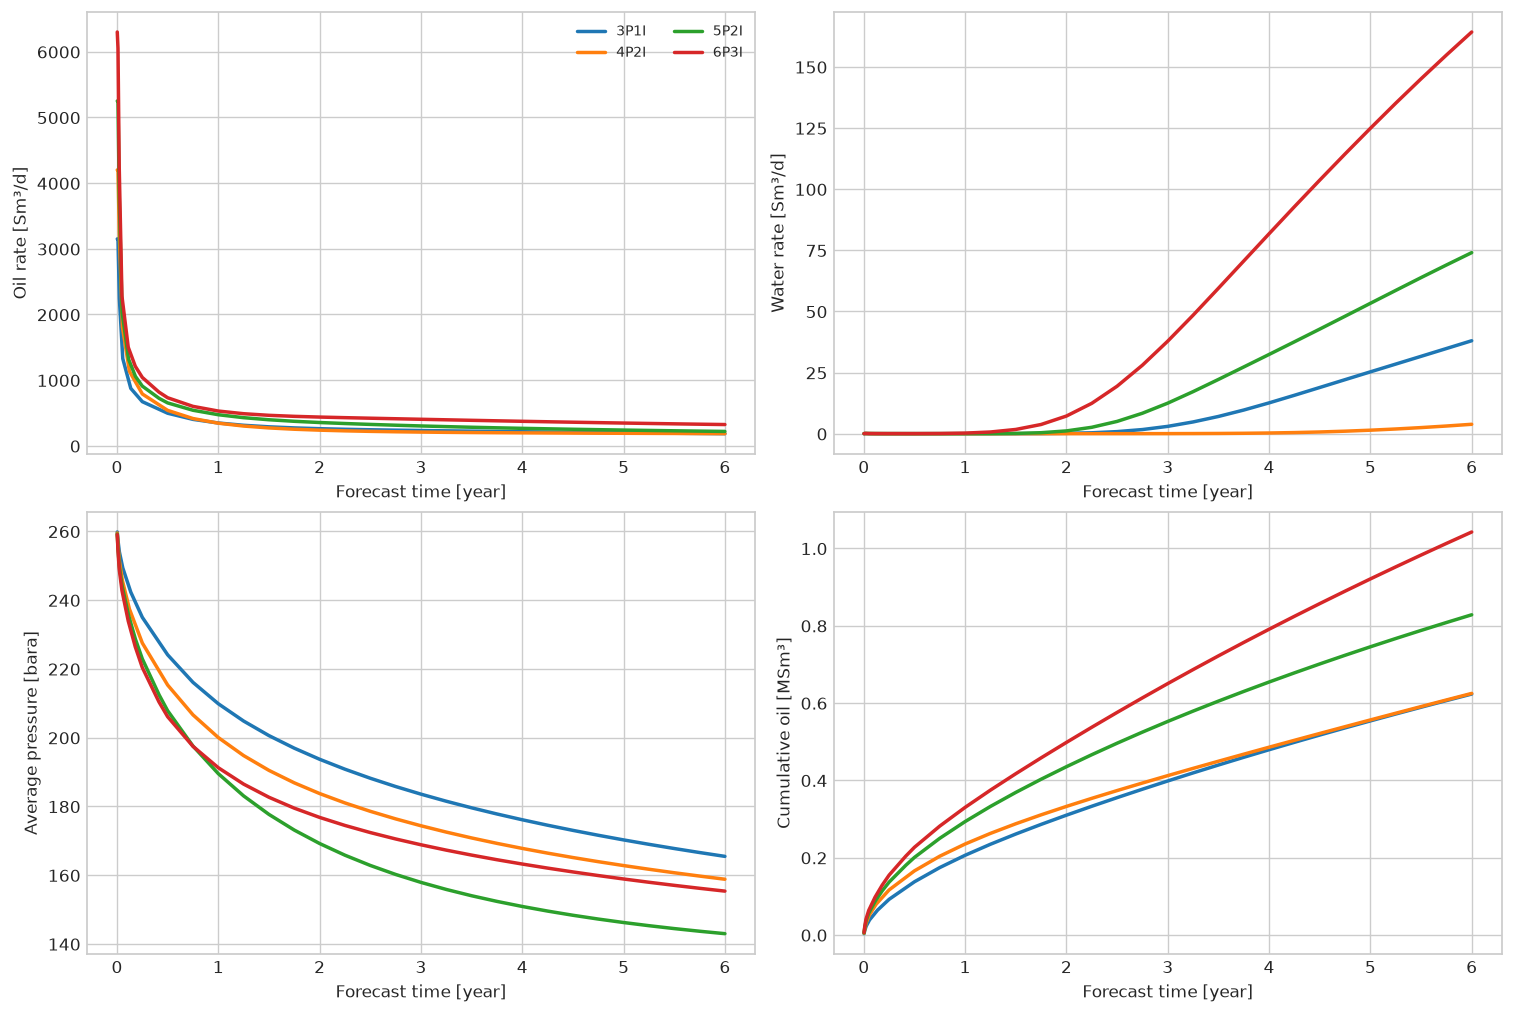

In [16]:
reservoir_summary_rows = []
for concept_name, history in reservoir_histories.items():
    initial_oil_rate = history["oil rate [Sm3/d]"].max()
    water_positive = history.loc[history["water rate [Sm3/d]"] > 1.0]
    breakthrough_year = (
        float(water_positive["time [day]"].iloc[0] / DAYS_PER_YEAR)
        if not water_positive.empty
        else np.nan
    )
    reservoir_summary_rows.append(
        {
            "concept": concept_name,
            "peak oil [Sm3/d]": initial_oil_rate,
            "oil at 6 y [MSm3]": history["cumulative oil [MSm3]"].iloc[-1],
            "final pressure [bara]": history["pressure [bara]"].iloc[-1],
            "peak water [Sm3/d]": history["water rate [Sm3/d]"].max(),
            "water breakthrough [year]": breakthrough_year,
            "injected water [MSm3]": history[
                "cumulative injection [MSm3]"
            ].iloc[-1],
        }
    )

reservoir_summary = pd.DataFrame(reservoir_summary_rows).sort_values(
    "oil at 6 y [MSm3]",
    ascending=False,
)
display(reservoir_summary)

forecast_figure, forecast_axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 8.0),
    constrained_layout=True,
)
plot_specs = [
    ("oil rate [Sm3/d]", "Oil rate [Sm³/d]"),
    ("water rate [Sm3/d]", "Water rate [Sm³/d]"),
    ("pressure [bara]", "Average pressure [bara]"),
    ("cumulative oil [MSm3]", "Cumulative oil [MSm³]"),
]
for axis, (column_name, y_label) in zip(forecast_axes.ravel(), plot_specs):
    for concept_name, history in reservoir_histories.items():
        axis.plot(
            history["time [day]"] / DAYS_PER_YEAR,
            history[column_name],
            linewidth=2.0,
            label=concept_name,
        )
    axis.set(xlabel="Forecast time [year]", ylabel=y_label)
forecast_axes[0, 0].legend(ncol=2)
plt.show()


## 8. Well, SURF, and NeqSim facility handoff

The OPM forecasts are now tested against the rest of the field system. The selected layout route
length estimates subsea scope. A Darcy-Weisbach screen estimates common flowline loss. The highest
oil-rate snapshot is reconstructed as a characterized multiphase NeqSim stream using an explicit
solution-GOR assumption, then choked, separated, compressed, and cooled.

This handoff is intentionally modular: the reservoir simulator owns reservoir conservation;
NeqSim owns phase behavior and process equipment. A calibrated multiphase flow simulator is still
required for terrain, severe slugging, cooldown, restart, hydrate, wax, erosion, and turndown.


In [17]:
def surf_pressure_drop_bar(liquid_rate_sm3_day, route_length_km):
    pipe_inner_diameter_m = 0.254
    liquid_density_kg_m3 = 820.0
    liquid_viscosity_pa_s = 1.2e-3
    roughness_m = 4.5e-5
    actual_rate_m3_s = liquid_rate_sm3_day / SECONDS_PER_DAY
    area_m2 = np.pi * pipe_inner_diameter_m**2 / 4.0
    velocity_m_s = actual_rate_m3_s / area_m2
    reynolds_number = (
        liquid_density_kg_m3
        * velocity_m_s
        * pipe_inner_diameter_m
        / liquid_viscosity_pa_s
    )
    friction_factor = (
        -1.8
        * np.log10(
            (roughness_m / pipe_inner_diameter_m / 3.7) ** 1.11
            + 6.9 / reynolds_number
        )
    ) ** -2
    pressure_drop_pa = (
        friction_factor
        * route_length_km
        * 1000.0
        / pipe_inner_diameter_m
        * liquid_density_kg_m3
        * velocity_m_s**2
        / 2.0
    )
    return pressure_drop_pa / BAR_TO_PA, velocity_m_s


system_screen_rows = []
for _, reservoir_row in reservoir_summary.iterrows():
    concept_name = reservoir_row["concept"]
    route_length_km = selected_layouts[concept_name]["objectives"][2]
    liquid_rate = (
        reservoir_row["peak oil [Sm3/d]"]
        + reservoir_row["peak water [Sm3/d]"]
    )
    pressure_drop_bar, velocity_m_s = surf_pressure_drop_bar(
        liquid_rate,
        route_length_km,
    )
    count_row = count_screen.loc[count_screen["concept"] == concept_name].iloc[0]
    system_screen_rows.append(
        {
            "concept": concept_name,
            "route length [km]": route_length_km,
            "flowline drop [bar]": pressure_drop_bar,
            "flowline velocity [m/s]": velocity_m_s,
            "oil capacity pass": (
                reservoir_row["peak oil [Sm3/d]"] <= 5600.0
            ),
            "water capacity pass": (
                reservoir_row["peak water [Sm3/d]"] <= 4800.0
            ),
            "dynamic oil target pass": (
                reservoir_row["peak oil [Sm3/d]"]
                >= 0.90 * FIELD_OIL_TARGET_SM3_DAY
            ),
            "count oil target pass": count_row["oil target met"],
            "count VRR pass": count_row["VRR target met"],
        }
    )

system_screen = pd.DataFrame(system_screen_rows)
display(system_screen)


,concept,route length [km],flowline drop [bar],flowline velocity [m/s],oil capacity pass,water capacity pass,dynamic oil target pass,count oil target pass,count VRR pass
0,6P3I,15.320253,8.725747,1.476544,False,True,True,True,True
1,5P2I,13.474884,5.338957,1.216100,True,True,True,True,True
2,4P2I,9.384570,2.396997,0.960231,True,True,True,True,True
3,3P1I,6.583146,1.009300,0.728195,True,True,False,True,False


In [18]:
preliminary_selected_concept = reservoir_summary.iloc[0]["concept"]
selected_history = reservoir_histories[preliminary_selected_concept]
peak_row = selected_history.loc[selected_history["oil rate [Sm3/d]"].idxmax()]

selected_oil_rate_sm3_day = float(peak_row["oil rate [Sm3/d]"])
selected_water_rate_sm3_day = float(peak_row["water rate [Sm3/d]"])
ASSUMED_SOLUTION_GOR_SM3_SM3 = 85.0
selected_gas_rate_sm3_day = (
    selected_oil_rate_sm3_day * ASSUMED_SOLUTION_GOR_SM3_SM3
)

oil_mass_rate_kg_s = selected_oil_rate_sm3_day * 820.0 / SECONDS_PER_DAY
water_mass_rate_kg_s = selected_water_rate_sm3_day * 1000.0 / SECONDS_PER_DAY
gas_mass_rate_kg_s = selected_gas_rate_sm3_day * 0.82 / SECONDS_PER_DAY

feed_fluid = jneqsim.thermo.system.SystemSrkCPAstatoil(333.15, 75.0)
gas_mass_split = {
    "methane": 0.82,
    "ethane": 0.10,
    "propane": 0.05,
    "CO2": 0.03,
}
oil_mass_split = {
    "n-hexane": 0.08,
    "n-heptane": 0.12,
    "n-octane": 0.20,
    "n-nonane": 0.20,
    "nC10": 0.20,
    "nC12": 0.20,
}

for component_name, mass_fraction in gas_mass_split.items():
    probe = jneqsim.thermo.system.SystemSrkEos(288.15, 1.01325)
    probe.addComponent(component_name, 1.0)
    molar_mass = probe.getComponent(component_name).getMolarMass()
    feed_fluid.addComponent(
        component_name,
        gas_mass_rate_kg_s * mass_fraction / molar_mass,
    )
for component_name, mass_fraction in oil_mass_split.items():
    probe = jneqsim.thermo.system.SystemSrkEos(288.15, 1.01325)
    probe.addComponent(component_name, 1.0)
    molar_mass = probe.getComponent(component_name).getMolarMass()
    feed_fluid.addComponent(
        component_name,
        oil_mass_rate_kg_s * mass_fraction / molar_mass,
    )
water_molar_mass = 0.01801528
feed_fluid.addComponent("water", water_mass_rate_kg_s / water_molar_mass)
feed_fluid.setMixingRule(10)
feed_fluid.setMultiPhaseCheck(True)
TPflash(feed_fluid)
feed_fluid.initPhysicalProperties()

clearProcess()
process_feed = stream("optimized field arrival", feed_fluid)
process_feed.setFlowRate(
    (oil_mass_rate_kg_s + gas_mass_rate_kg_s + water_mass_rate_kg_s)
    * 3600.0,
    "kg/hr",
)
inlet_choke = valve("inlet choke", process_feed, 45.0)
first_stage_separator = separator3phase(
    "first-stage separator",
    inlet_choke.getOutletStream(),
)
export_compressor = compressor(
    "export compressor",
    first_stage_separator.getGasOutStream(),
    120.0,
)
export_compressor.setIsentropicEfficiency(0.76)
aftercooler = cooler(
    "export aftercooler",
    export_compressor.getOutletStream(),
)
aftercooler.setOutTemperature(35.0, "C")
runProcess()

feed_mass_kg_h = process_feed.getFlowRate("kg/hr")
outlet_mass_kg_h = sum(
    stream_object.getFlowRate("kg/hr")
    for stream_object in [
        first_stage_separator.getGasOutStream(),
        first_stage_separator.getOilOutStream(),
        first_stage_separator.getWaterOutStream(),
    ]
)
separator_mass_residual = outlet_mass_kg_h - feed_mass_kg_h

process_summary = pd.DataFrame(
    [
        ("concept", preliminary_selected_concept, "-"),
        ("oil feed", selected_oil_rate_sm3_day, "Sm³/d"),
        ("gas feed", selected_gas_rate_sm3_day, "Sm³/d"),
        ("water feed", selected_water_rate_sm3_day, "Sm³/d"),
        ("compressor power", export_compressor.getPower("MW"), "MW"),
        ("aftercooler duty", aftercooler.getDuty() / 1.0e6, "MW"),
        ("separator mass residual", separator_mass_residual, "kg/h"),
    ],
    columns=["quantity", "value", "unit"],
)
display(process_summary)


,quantity,value,unit
0,concept,6P3I,-
1,oil feed,6300.0,Sm³/d
2,gas feed,535500.0,Sm³/d
3,water feed,0.03977,Sm³/d
4,compressor power,0.676654,MW
5,aftercooler duty,-1.09324,MW
6,separator mass residual,-0.0,kg/h


## 9. Integrated economics and uncertainty

Field oil is curtailed at the host capacity before revenue is calculated. The pre-tax brownfield
tie-back cash flow includes producer, injector, SURF, host-modification, operating,
water-handling, and abandonment assumptions. It is intentionally simple, incremental to the
existing host, and uses constant 2026 USD.

$$\mathrm{NPV}=\sum_{t=0}^{N}\frac{R_t-O_t-I_t}{(1+r)^t}$$

The uncertainty loop varies oil price, recoverable-rate multiplier, CAPEX, OPEX, and drilling
duration. For this value metric, petroleum convention is used: P90 is the conservative 10th
percentile, P50 is the median, and P10 is the upside 90th percentile. It is a decision-risk
illustration; geological uncertainty should ultimately rerun OPM Flow with an ensemble manager
such as ERT.


In [19]:
OIL_PRICE_USD_BBL = 78.0
OIL_CAPACITY_SM3_DAY = 5600.0
DISCOUNT_RATE = 0.08
PRODUCER_COST_MUSD = 25.0
INJECTOR_COST_MUSD = 18.0
FACILITY_CAPEX_MUSD = 35.0
SURF_COST_MUSD_KM = 3.5
FIXED_OPEX_MUSD_YEAR = 8.0
VARIABLE_OPEX_USD_BBL = 7.0
WATER_HANDLING_USD_M3 = 3.0
ABANDONMENT_MUSD = 20.0


def concept_cash_flow(concept_name, oil_price=OIL_PRICE_USD_BBL):
    history = reservoir_histories[concept_name].copy()
    layout = selected_layouts[concept_name]
    producer_count, injector_count = COUNT_CONCEPTS[concept_name]
    rows = []
    for year_index in range(1, 7):
        year_start = (year_index - 1) * DAYS_PER_YEAR
        year_end = year_index * DAYS_PER_YEAR
        year_history = history.loc[
            (history["time [day]"] > year_start)
            & (history["time [day]"] <= year_end)
        ]
        if year_history.empty:
            continue
        oil_rate = np.minimum(
            year_history["oil rate [Sm3/d]"],
            OIL_CAPACITY_SM3_DAY,
        )
        water_rate = np.minimum(
            year_history["water rate [Sm3/d]"],
            4800.0,
        )
        annual_oil_sm3 = oil_rate.mean() * DAYS_PER_YEAR
        annual_water_m3 = water_rate.mean() * DAYS_PER_YEAR
        annual_oil_bbl = annual_oil_sm3 * 6.28981
        revenue_musd = annual_oil_bbl * oil_price / 1.0e6
        variable_opex_musd = (
            annual_oil_bbl * VARIABLE_OPEX_USD_BBL
            + annual_water_m3 * WATER_HANDLING_USD_M3
        ) / 1.0e6
        rows.append(
            {
                "year": year_index,
                "revenue [MUSD]": revenue_musd,
                "opex [MUSD]": FIXED_OPEX_MUSD_YEAR + variable_opex_musd,
                "investment [MUSD]": 0.0,
            }
        )

    capex_musd = (
        producer_count * PRODUCER_COST_MUSD
        + injector_count * INJECTOR_COST_MUSD
        + FACILITY_CAPEX_MUSD
        + layout["objectives"][2] * SURF_COST_MUSD_KM
    )
    cash_flow = pd.DataFrame(rows)
    year_zero = pd.DataFrame(
        [
            {
                "year": 0,
                "revenue [MUSD]": 0.0,
                "opex [MUSD]": 0.0,
                "investment [MUSD]": capex_musd,
            }
        ]
    )
    cash_flow = pd.concat([year_zero, cash_flow], ignore_index=True)
    cash_flow.loc[cash_flow.index[-1], "investment [MUSD]"] += ABANDONMENT_MUSD
    cash_flow["net cash flow [MUSD]"] = (
        cash_flow["revenue [MUSD]"]
        - cash_flow["opex [MUSD]"]
        - cash_flow["investment [MUSD]"]
    )
    cash_flow["discounted cash flow [MUSD]"] = (
        cash_flow["net cash flow [MUSD]"]
        / (1.0 + DISCOUNT_RATE) ** cash_flow["year"]
    )
    return cash_flow, capex_musd


economic_rows = []
cash_flows = {}
for concept_name in COUNT_CONCEPTS:
    cash_flow, capex_musd = concept_cash_flow(concept_name)
    cash_flows[concept_name] = cash_flow
    system_row = system_screen.loc[
        system_screen["concept"] == concept_name
    ].iloc[0]
    economic_rows.append(
        {
            "concept": concept_name,
            "CAPEX [MUSD]": capex_musd,
            "NPV [MUSD]": cash_flow["discounted cash flow [MUSD]"].sum(),
            "oil capacity pass": system_row["oil capacity pass"],
            "water capacity pass": system_row["water capacity pass"],
            "dynamic oil target pass": system_row["dynamic oil target pass"],
            "count oil target pass": system_row["count oil target pass"],
            "count VRR pass": system_row["count VRR pass"],
        }
    )

economic_summary = pd.DataFrame(economic_rows).sort_values(
    "NPV [MUSD]",
    ascending=False,
)
economic_summary["all hard screens pass"] = economic_summary[
    [
        "oil capacity pass",
        "water capacity pass",
        "dynamic oil target pass",
        "count oil target pass",
        "count VRR pass",
    ]
].all(axis=1)
display(economic_summary)


,concept,CAPEX [MUSD],NPV [MUSD],oil capacity pass,water capacity pass,dynamic oil target pass,count oil target pass,count VRR pass,all hard screens pass
3,6P3I,292.620887,227.301085,False,True,True,True,True,False
2,5P2I,243.162095,189.326045,True,True,True,True,True,True
1,4P2I,203.845995,155.810842,True,True,True,True,True,True
0,3P1I,151.041010,151.649423,True,True,False,True,False,False


,concept,P90,P50,P10,probability_positive
0,3P1I,51.783142,142.327423,263.156728,0.978
1,4P2I,42.076329,151.737840,296.742664,0.966
2,5P2I,54.575100,181.417311,333.788268,0.980
3,6P3I,54.984655,210.369080,402.216485,0.972


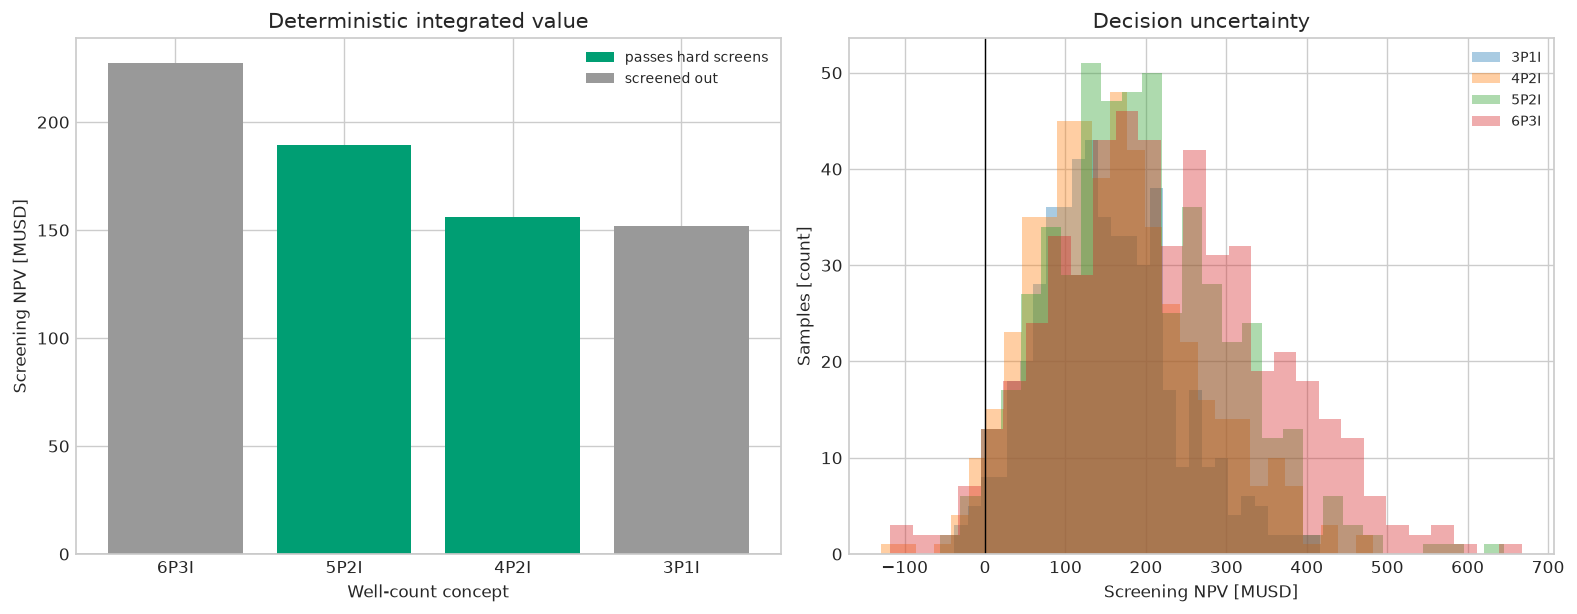

In [20]:
UNCERTAINTY_SAMPLES = 500
uncertainty_rows = []

for concept_name in COUNT_CONCEPTS:
    base_cash_flow = cash_flows[concept_name]
    base_capex = economic_summary.loc[
        economic_summary["concept"] == concept_name,
        "CAPEX [MUSD]",
    ].iloc[0]
    for sample_index in range(UNCERTAINTY_SAMPLES):
        oil_price = random_generator.triangular(52.0, 75.0, 105.0)
        reservoir_multiplier = np.exp(random_generator.normal(0.0, 0.14))
        capex_multiplier = np.exp(random_generator.normal(0.0, 0.12))
        opex_multiplier = np.exp(random_generator.normal(0.0, 0.10))

        scenario_cash_flow = base_cash_flow.copy()
        scenario_cash_flow["revenue [MUSD]"] *= (
            oil_price / OIL_PRICE_USD_BBL * reservoir_multiplier
        )
        scenario_cash_flow["opex [MUSD]"] *= opex_multiplier
        scenario_cash_flow.loc[0, "investment [MUSD]"] = (
            base_capex * capex_multiplier
        )
        scenario_cash_flow.loc[
            scenario_cash_flow.index[-1],
            "investment [MUSD]",
        ] = ABANDONMENT_MUSD * capex_multiplier
        scenario_cash_flow["net [MUSD]"] = (
            scenario_cash_flow["revenue [MUSD]"]
            - scenario_cash_flow["opex [MUSD]"]
            - scenario_cash_flow["investment [MUSD]"]
        )
        scenario_npv = np.sum(
            scenario_cash_flow["net [MUSD]"]
            / (1.0 + DISCOUNT_RATE) ** scenario_cash_flow["year"]
        )
        uncertainty_rows.append(
            {
                "concept": concept_name,
                "sample": sample_index,
                "oil price [USD/bbl]": oil_price,
                "reservoir multiplier": reservoir_multiplier,
                "CAPEX multiplier": capex_multiplier,
                "OPEX multiplier": opex_multiplier,
                "NPV [MUSD]": scenario_npv,
            }
        )

uncertainty_table = pd.DataFrame(uncertainty_rows)
uncertainty_summary = (
    uncertainty_table.groupby("concept")["NPV [MUSD]"]
    .agg(
        P90=lambda values: np.quantile(values, 0.10),
        P50="median",
        P10=lambda values: np.quantile(values, 0.90),
        probability_positive=lambda values: np.mean(values > 0.0),
    )
    .reset_index()
)
display(uncertainty_summary)

decision_figure, decision_axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.8),
    constrained_layout=True,
)
bar_colors = [
    "#009E73" if passes else "#999999"
    for passes in economic_summary["all hard screens pass"]
]
decision_axes[0].bar(
    economic_summary["concept"],
    economic_summary["NPV [MUSD]"],
    color=bar_colors,
)
decision_axes[0].legend(
    handles=[
        Patch(facecolor="#009E73", label="passes hard screens"),
        Patch(facecolor="#999999", label="screened out"),
    ]
)
decision_axes[0].axhline(0.0, color="black", linewidth=0.8)
decision_axes[0].set(
    title="Deterministic integrated value",
    xlabel="Well-count concept",
    ylabel="Screening NPV [MUSD]",
)
for concept_name, values in uncertainty_table.groupby("concept"):
    decision_axes[1].hist(
        values["NPV [MUSD]"],
        bins=28,
        alpha=0.38,
        label=concept_name,
    )
decision_axes[1].axvline(0.0, color="black", linewidth=0.8)
decision_axes[1].set(
    title="Decision uncertainty",
    xlabel="Screening NPV [MUSD]",
    ylabel="Samples [count]",
)
decision_axes[1].legend()
plt.show()


## 10. Decision rule and engineering interpretation

The recommended screening concept must pass all hard count and facility screens. Among feasible
concepts, deterministic NPV is the primary ranking and P90/P50/P10 show whether the decision is
fragile. A real team would also test reserves, drilling sequence, well availability, intervention,
gas lift, injection-water supply/quality, emissions, host shutdowns, export constraints, and partner
or regulatory requirements.


In [21]:
feasible_economics = economic_summary.loc[
    economic_summary["all hard screens pass"]
].copy()
if feasible_economics.empty:
    raise RuntimeError("No well-count concept passes the integrated hard screens.")

recommended_concept = feasible_economics.iloc[0]["concept"]
recommended_layout = selected_layouts[recommended_concept]
recommended_uncertainty = uncertainty_summary.loc[
    uncertainty_summary["concept"] == recommended_concept
].iloc[0]
recommended_reservoir = reservoir_summary.loc[
    reservoir_summary["concept"] == recommended_concept
].iloc[0]

producer_coordinates = [
    [int(location[0]) + 1, int(location[1]) + 1]
    for location in recommended_layout["producers"]
]
injector_coordinates = [
    [int(location[0]) + 1, int(location[1]) + 1]
    for location in recommended_layout["injectors"]
]

decision_summary = {
    "recommended_screening_concept": recommended_concept,
    "producer_cells_one_based": producer_coordinates,
    "injector_cells_one_based": injector_coordinates,
    "oil_at_6_years_MSm3": float(recommended_reservoir["oil at 6 y [MSm3]"]),
    "final_pressure_bara": float(recommended_reservoir["final pressure [bara]"]),
    "deterministic_NPV_MUSD": float(feasible_economics.iloc[0]["NPV [MUSD]"]),
    "NPV_P90_MUSD": float(recommended_uncertainty["P90"]),
    "NPV_P50_MUSD": float(recommended_uncertainty["P50"]),
    "NPV_P10_MUSD": float(recommended_uncertainty["P10"]),
    "probability_NPV_positive": float(
        recommended_uncertainty["probability_positive"]
    ),
}
print(json.dumps(decision_summary, indent=2, sort_keys=True))


{
  "NPV_P10_MUSD": 333.78826816246817,
  "NPV_P50_MUSD": 181.41731057698274,
  "NPV_P90_MUSD": 54.57509968239275,
  "deterministic_NPV_MUSD": 189.3260448300011,
  "final_pressure_bara": 142.9722137451172,
  "injector_cells_one_based": [
    [
      20,
      14
    ],
    [
      10,
      14
    ]
  ],
  "oil_at_6_years_MSm3": 0.828107375,
  "probability_NPV_positive": 0.98,
  "producer_cells_one_based": [
    [
      6,
      20
    ],
    [
      4,
      7
    ],
    [
      17,
      15
    ],
    [
      10,
      9
    ],
    [
      21,
      17
    ]
  ],
  "recommended_screening_concept": "5P2I"
}


## 11. Executable engineering validation

The checks cover package provenance, geometry, SCAL endpoints, count arithmetic, optimization
feasibility, dynamic simulation completion, monotone cumulative volumes, physical pressure/rate
bounds, NeqSim PVT contracts, separator mass closure, capacity gates, and decision consistency.


In [22]:
validation_checks = {}


def check(description, condition):
    passed = bool(condition)
    validation_checks[description] = passed
    if not passed:
        raise AssertionError(description)


check("NeqSim version pinned", installed_version("neqsim") == "3.17.0")
check("pymoo version pinned", installed_version("pymoo") == "0.6.2")
check("pyscal version pinned", installed_version("pyscal") == "0.15.3")
check("OPM Python version pinned", installed_version("opm") == "2026.4")
check("OPM Flow version identified", flow_version_match.group(1) == "2026.04")
check("candidate set is nontrivial", len(candidate_locations) >= 40)
check("porosity remains physical", np.all((porosity > 0.0) & (porosity < 0.40)))
check("permeability remains positive", np.all(permeability_realizations_md > 0.0))
check("pyscal water endpoint closes", np.isclose(scal_table["KRW"].iloc[0], 0.0))
check("pyscal oil endpoint closes", np.isclose(scal_table["KROW"].iloc[-1], 0.0))
check("radial producer rate positive", SAFE_PRODUCER_RATE_SM3_DAY > 0.0)
check("radial injector rate positive", SAFE_INJECTOR_RATE_SM3_DAY > 0.0)
check(
    "all selected layouts satisfy constraints",
    all(layout["constraints"].max() <= 1.0e-9 for layout in selected_layouts.values()),
)
check(
    "all layouts retain exact well counts",
    all(
        len(layout["producers"]) == COUNT_CONCEPTS[name][0]
        and len(layout["injectors"]) == COUNT_CONCEPTS[name][1]
        for name, layout in selected_layouts.items()
    ),
)
check("all PVT contracts pass", pvt_checks["passed"].all())
check("all Flow cases return success", (flow_run_table["return code"] == 0).all())
check("all Flow cases report completion", flow_run_table["completion marker"].all())
check("all Flow summaries exist", flow_run_table["summary exists"].all())
check(
    "cumulative oil is monotone",
    all(
        np.all(np.diff(history["cumulative oil [MSm3]"]) >= -1.0e-10)
        for history in reservoir_histories.values()
    ),
)
check(
    "reservoir pressure remains physical",
    reservoir_summary["final pressure [bara]"].between(40.0, 340.0).all(),
)
check(
    "production and injection rates are nonnegative",
    all(
        (history[[
            "oil rate [Sm3/d]",
            "water rate [Sm3/d]",
            "water injection [Sm3/d]",
        ]] >= 0.0).all().all()
        for history in reservoir_histories.values()
    ),
)
check(
    "separator mass balance closes",
    abs(separator_mass_residual) <= max(1.0e-6, feed_mass_kg_h * 1.0e-8),
)
check("at least one integrated concept is feasible", not feasible_economics.empty)
check(
    "recommendation is the highest-NPV feasible concept",
    recommended_concept == feasible_economics.iloc[0]["concept"],
)
check(
    "recommended screening NPV is positive",
    feasible_economics.iloc[0]["NPV [MUSD]"] > 0.0,
)
check(
    "uncertainty ordering is correct",
    recommended_uncertainty["P90"]
    <= recommended_uncertainty["P50"]
    <= recommended_uncertainty["P10"],
)

validation_table = pd.DataFrame(
    {
        "check": list(validation_checks),
        "passed": list(validation_checks.values()),
    }
)
display(validation_table)
print(f"All {len(validation_checks)} engineering checks passed.")


All 26 engineering checks passed.


,check,passed
0,NeqSim version pinned,True
1,pymoo version pinned,True
2,pyscal version pinned,True
3,OPM Python version pinned,True
4,OPM Flow version identified,True
5,candidate set is nontrivial,True
6,porosity remains physical,True
7,permeability remains positive,True
8,pyscal water endpoint closes,True
9,pyscal oil endpoint closes,True


## Results and handoff

Use the selected cells only as a reproducible screening layout. The durable handoff is the complete
set of objectives, assumptions, alternative layouts, OPM decks/results, well controls, process
loads, capacity checks, economics, uncertainty, and validation evidence. A discipline team can
replace each synthetic input without changing the workflow contracts.

The key decision sequence is:

1. Reject concepts that cannot meet producer deliverability or injector VRR with margin.
2. Compare Pareto layouts within each surviving count concept.
3. Verify the layouts with dynamic pressure, saturation, rate, and breakthrough behavior.
4. Apply well, SURF, host, water, gas, power, flow-assurance, and operating constraints.
5. Compare incremental recovery and acceleration against complete lifecycle cost and downside.
6. Mature the recommendation through uncertainty, drilling, completion, and assurance gates.


## Limitations and next engineering steps

- Replace the synthetic grid with quality-controlled seismic interpretation, static realizations,
  petrophysics, contacts, faults, aquifer, SCAL, PVT, pressure, and history data.
- Use horizontal/deviated trajectories, completion intervals, wellbore hydraulics, skin, lift,
  injection-water quality, fracture pressure, conformance, drilling reach, anti-collision, and
  intervention constraints.
- Run simulator-in-the-loop robust optimization across a history-matched OPM Flow ensemble. ERT is
  suitable for orchestration; surrogate models should be validated and updated adaptively.
- Add group controls, facility backpressure, gas lift/ESP, compressor maps, water-treatment and
  injection-pump limits, availability, maintenance, and drilling sequence.
- Replace screening SURF pressure loss with terrain-aware steady and transient multiphase analysis.
- Apply project-specific cost, schedule, fiscal, emissions, abandonment, and decision criteria.
- Treat P&ID, well design, reserves, project sanction, and investment claims as accountable
  engineering decisions outside this notebook.


## Related NeqSim-Colab workflows

- [Volve full field development with OPM Flow and NeqSim](volve_full_field_development_opm_neqsim.ipynb)
  compares manually defined well-count/layout concepts through a broader field-development study.
- [Rock-derived productivity and injectivity](../well/rock_derived_productivity_injectivity_opm_neqsim.ipynb)
  derives inflow and injection capacity from PTA, SCAL, OPM Flow, and NeqSim well models.
- [NeqSim + OPM Flow black-oil coupling](../reservoir/neqsim_opm_flow_blackoil_coupling.ipynb)
  provides the detailed compositional-to-black-oil-to-surface handoff.
- [ERT + NeqSim integrated field-development uncertainty](../reservoir/ert_neqsim_integrated_field_development.ipynb)
  shows how to propagate uncertainty across reservoir, wells, SURF, process, and economics.
- [Complete oil and gas value chain with NeqSim](../valuechain/complete_oil_and_gas_value_chain_with_neqsim.ipynb)
  places the well decision inside discovery, concept, project, operation, and abandonment stages.


## References and package roles

- [pymoo NSGA-II](https://pymoo.org/algorithms/moo/nsga2.html) and
  [discrete-variable optimization](https://pymoo.org/customization/discrete.html): constrained
  multi-objective layout search.
- [OPM Flow](https://opm-project.org/) and the
  [OPM Flow manual](https://opm-project.org/?page_id=955): fully implicit oil/water reservoir
  verification and simulator contracts.
- [Equinor pyscal](https://github.com/equinor/pyscal): consistent relative-permeability functions
  and OPM table export.
- [NeqSim](https://equinor.github.io/neqsim/): PVT, phase behavior, wells, process, and
  surface-facility calculations.
- Rasmussen et al. (2021), *The Open Porous Media Flow reservoir simulator*,
  [doi:10.1016/j.camwa.2020.05.014](https://doi.org/10.1016/j.camwa.2020.05.014).

Suggested exercises: change the fault exclusion, add one gas injector concept, require an
intervention spare, optimize first-well and injector conversion timing, or rerun the Pareto search
for a constrained brownfield host.


## Saved-notebook validation record

The repository maintenance ledger records the clean execution method, pinned versions, OPM Flow
case count, named engineering assertions, stored outputs, MathJax rendering, and visual inspection
of every equation, table, and figure. The saved notebook contains no proprietary data or credentials.
